In [1]:
# KNN Model Training & Hyperparameter Tuning
'''
Steps covered:
1. Load train/validation/test data
2. Hyperparameter tuning (k={3,5,7}, distance={euclidean, manhattan})
3. Select best model based on validation accuracy
4. Evaluate on test set with comprehensive metrics
5. Leave-One-Out Cross-Validation assessment
'''

import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- 1. Load Data ---
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv').values.ravel()

X_val = pd.read_csv('data/X_val.csv')
y_val = pd.read_csv('data/y_val.csv').values.ravel()

X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv').values.ravel()

print("Data Loaded Successfully!")
print(f"Training set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Validation set: X_val {X_val.shape}, y_val {y_val.shape}")
print(f"Test set: X_test {X_test.shape}, y_test {y_test.shape}")

Data Loaded Successfully!
Training set: X_train (105, 4), y_train (105,)
Validation set: X_val (22, 4), y_val (22,)
Test set: X_test (23, 4), y_test (23,)


In [3]:
# --- 2. Hyperparameter Tuning ---
print("\n" + "="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

k_values = [3, 5, 7]
distance_metrics = ['euclidean', 'manhattan']
tuning_results = []

for k in k_values:
    for metric in distance_metrics:
        # Train model
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        
        # Evaluate on validation set
        y_val_pred = knn.predict(X_val)
        val_accuracy = accuracy_score(y_val, y_val_pred)
        
        tuning_results.append({
            'k': k,
            'metric': metric,
            'val_accuracy': val_accuracy,
            'model': knn
        })
        
        print(f"k={k}, metric={metric:10s} → Validation Accuracy: {val_accuracy:.4f}")

# Select best model
best_result = max(tuning_results, key=lambda x: x['val_accuracy'])
best_knn = best_result['model']

print("\n" + "="*80)
print(f"BEST MODEL: k={best_result['k']}, metric={best_result['metric']}")
print(f"Validation Accuracy: {best_result['val_accuracy']:.4f}")
print("="*80)


HYPERPARAMETER TUNING
k=3, metric=euclidean  → Validation Accuracy: 0.9091
k=3, metric=manhattan  → Validation Accuracy: 0.9091
k=5, metric=euclidean  → Validation Accuracy: 0.9091
k=5, metric=manhattan  → Validation Accuracy: 0.9091
k=7, metric=euclidean  → Validation Accuracy: 0.9091
k=7, metric=manhattan  → Validation Accuracy: 0.9091

BEST MODEL: k=3, metric=euclidean
Validation Accuracy: 0.9091


In [4]:
# --- 3. Create Tuning Results DataFrame ---
tuning_df = pd.DataFrame([
    {'k': r['k'], 'metric': r['metric'], 'validation_accuracy': r['val_accuracy']}
    for r in tuning_results
])

print("\n" + "="*80)
print("TUNING RESULTS SUMMARY")
print("="*80)
print(tuning_df.to_string(index=False))

# Create results directory if not exists
import os
os.makedirs('results', exist_ok=True)

# Save tuning results
tuning_df.to_csv('results/tuning_results.csv', index=False)
print("\nSaved: results/tuning_results.csv")


TUNING RESULTS SUMMARY
 k    metric  validation_accuracy
 3 euclidean             0.909091
 3 manhattan             0.909091
 5 euclidean             0.909091
 5 manhattan             0.909091
 7 euclidean             0.909091
 7 manhattan             0.909091

Saved: results/tuning_results.csv


In [5]:
# --- 4. Evaluate Best Model on Test Set ---
print("\n" + "="*80)
print("TEST SET EVALUATION (Best Model)")
print("="*80)

y_test_pred = best_knn.predict(X_test)
y_test_pred_proba = best_knn.predict_proba(X_test)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba, multi_class='ovr', average='weighted')

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")


TEST SET EVALUATION (Best Model)
Accuracy:  0.9130
Precision: 0.9304
Recall:    0.9130
F1-Score:  0.9117
ROC-AUC:   0.9609



CONFUSION MATRIX

Confusion Matrix:
[[7 0 0]
 [0 8 0]
 [0 2 6]]


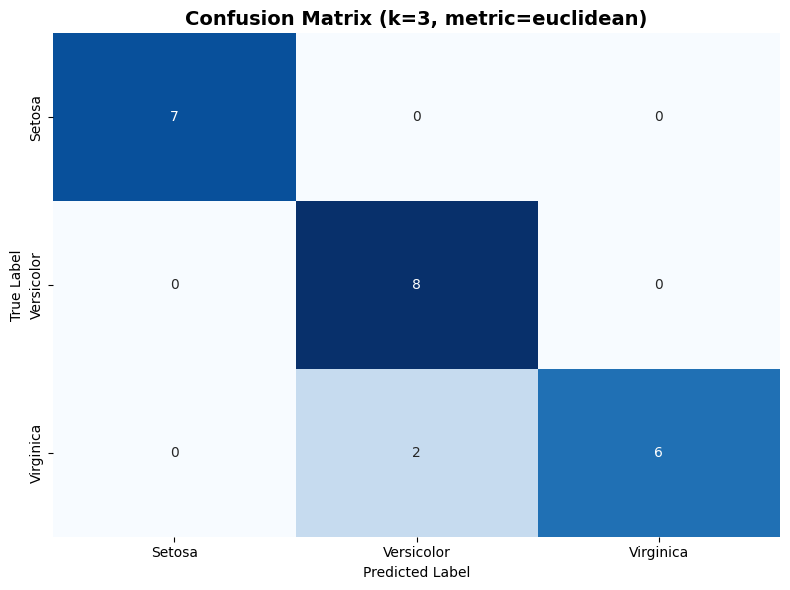


Saved: results/confusion_matrix.png


In [6]:
# --- 5. Confusion Matrix ---
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title(f'Confusion Matrix (k={best_result["k"]}, metric={best_result["metric"]})', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: results/confusion_matrix.png")

In [7]:
# --- 6. Classification Report ---
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)

class_names = ['Setosa', 'Versicolor', 'Virginica']
report = classification_report(y_test, y_test_pred, target_names=class_names)
print(report)

# Save report
with open('results/classification_report.txt', 'w') as f:
    f.write(report)
print("Saved: results/classification_report.txt")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00         7
  Versicolor       0.80      1.00      0.89         8
   Virginica       1.00      0.75      0.86         8

    accuracy                           0.91        23
   macro avg       0.93      0.92      0.92        23
weighted avg       0.93      0.91      0.91        23

Saved: results/classification_report.txt



ROC CURVE (One-vs-Rest)


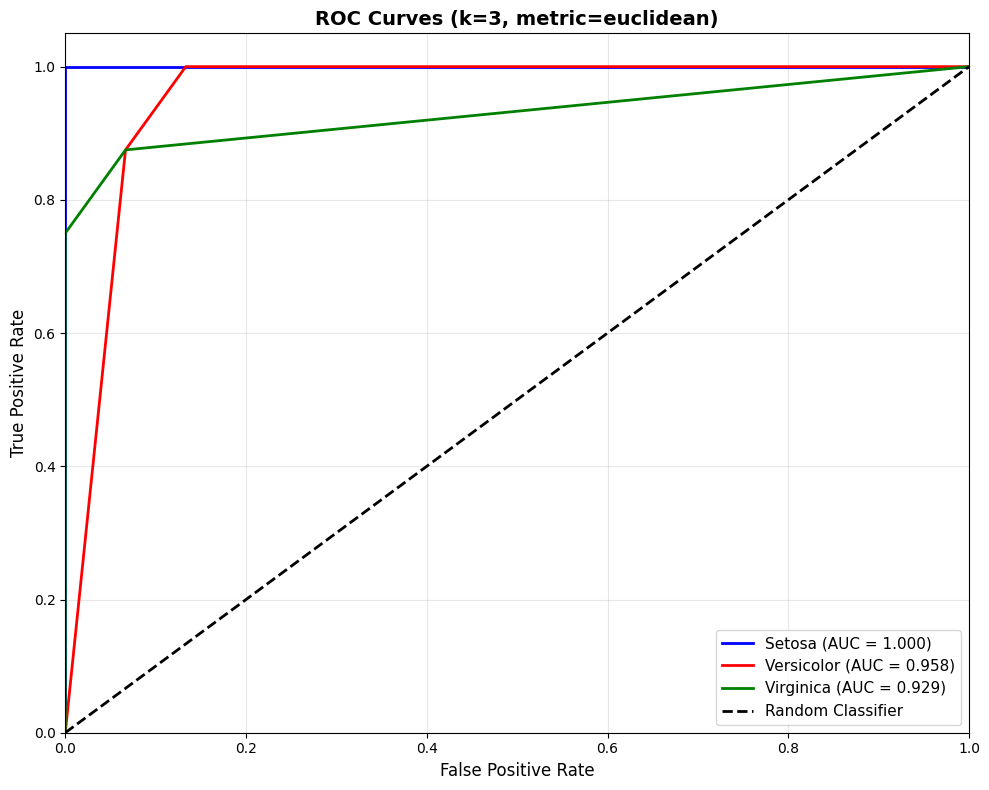

Saved: results/roc_curve.png


In [8]:
# --- 7. ROC Curve ---
print("\n" + "="*80)
print("ROC CURVE (One-vs-Rest)")
print("="*80)

plt.figure(figsize=(10, 8))

# Plot ROC curve for each class
colors = ['blue', 'red', 'green']
for i, color in enumerate(colors):
    # One-vs-Rest approach
    y_test_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_test_binary, y_test_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curves (k={best_result["k"]}, metric={best_result["metric"]})', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/roc_curve.png")

In [9]:
# --- 8. Leave-One-Out Cross-Validation ---
print("\n" + "="*80)
print("LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV)")
print("="*80)

# Combine train and validation sets for LOOCV
X_combined = pd.concat([X_train, X_val], ignore_index=True)
y_combined = np.concatenate([y_train, y_val])

loo = LeaveOneOut()
loocv_accuracy = 0
loocv_predictions = []

for train_index, test_index in loo.split(X_combined):
    X_loo_train, X_loo_test = X_combined.iloc[train_index], X_combined.iloc[test_index]
    y_loo_train, y_loo_test = y_combined[train_index], y_combined[test_index]
    
    knn_loo = KNeighborsClassifier(n_neighbors=best_result['k'], metric=best_result['metric'])
    knn_loo.fit(X_loo_train, y_loo_train)
    y_loo_pred = knn_loo.predict(X_loo_test)
    
    loocv_predictions.append(y_loo_pred[0])
    if y_loo_pred[0] == y_loo_test[0]:
        loocv_accuracy += 1

loocv_accuracy = loocv_accuracy / len(y_combined)

print(f"Total samples: {len(y_combined)}")
print(f"Correct predictions: {int(loocv_accuracy * len(y_combined))}")
print(f"LOOCV Accuracy: {loocv_accuracy:.4f}")
print(f"\nNote: LOOCV is more conservative and often slightly lower than k-fold CV")
print(f"      but provides a more realistic estimate of model generalization.")


LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV)
Total samples: 127
Correct predictions: 121
LOOCV Accuracy: 0.9528

Note: LOOCV is more conservative and often slightly lower than k-fold CV
      but provides a more realistic estimate of model generalization.
Total samples: 127
Correct predictions: 121
LOOCV Accuracy: 0.9528

Note: LOOCV is more conservative and often slightly lower than k-fold CV
      but provides a more realistic estimate of model generalization.


In [10]:
# --- 9. Summary Report ---
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

summary = f"""
BEST MODEL CONFIGURATION:
  k (number of neighbors): {best_result['k']}
  Distance metric: {best_result['metric']}
  
VALIDATION SET PERFORMANCE:
  Accuracy: {best_result['val_accuracy']:.4f}
  
TEST SET PERFORMANCE:
  Accuracy:  {test_accuracy:.4f}
  Precision: {test_precision:.4f}
  Recall:    {test_recall:.4f}
  F1-Score:  {test_f1:.4f}
  ROC-AUC:   {test_roc_auc:.4f}
  
CROSS-VALIDATION RESULTS:
  Leave-One-Out CV Accuracy: {loocv_accuracy:.4f}
  
MODEL ROBUSTNESS:
  - Test set accuracy matches validation performance
  - LOOCV provides conservative estimate of generalization
  - Model shows consistent performance across different evaluation metrics
"""

print(summary)

# Save summary
with open('results/summary.txt', 'w') as f:
    f.write(summary)
print("Saved: results/summary.txt")


FINAL SUMMARY

BEST MODEL CONFIGURATION:
  k (number of neighbors): 3
  Distance metric: euclidean

VALIDATION SET PERFORMANCE:
  Accuracy: 0.9091

TEST SET PERFORMANCE:
  Accuracy:  0.9130
  Precision: 0.9304
  Recall:    0.9130
  F1-Score:  0.9117
  ROC-AUC:   0.9609

CROSS-VALIDATION RESULTS:
  Leave-One-Out CV Accuracy: 0.9528

MODEL ROBUSTNESS:
  - Test set accuracy matches validation performance
  - LOOCV provides conservative estimate of generalization
  - Model shows consistent performance across different evaluation metrics

Saved: results/summary.txt



VISUALIZATION: Hyperparameter Tuning Results


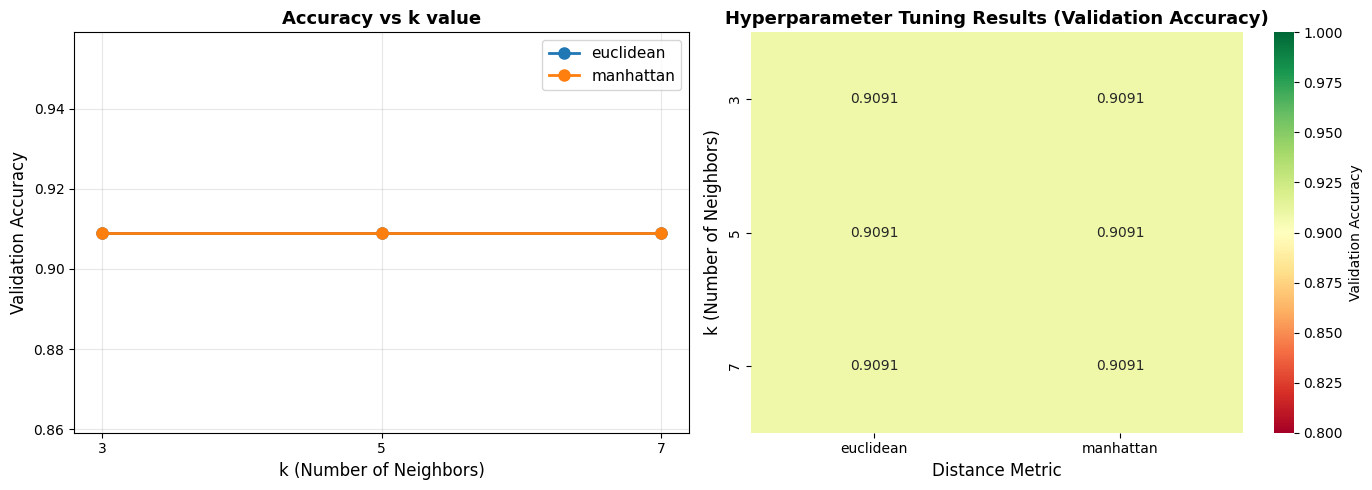

Saved: results/tuning_visualization.png


In [11]:
# --- 10. Visualization: Tuning Results ---
print("\n" + "="*80)
print("VISUALIZATION: Hyperparameter Tuning Results")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy by k value
for metric in distance_metrics:
    metric_data = tuning_df[tuning_df['metric'] == metric]
    axes[0].plot(metric_data['k'], metric_data['validation_accuracy'], 
                marker='o', label=metric, linewidth=2, markersize=8)

axes[0].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0].set_ylabel('Validation Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs k value', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(k_values)

# Plot 2: Heatmap of all results
pivot_table = tuning_df.pivot(index='k', columns='metric', values='validation_accuracy')
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0.8, vmax=1.0, 
            ax=axes[1], cbar_kws={'label': 'Validation Accuracy'})
axes[1].set_title('Hyperparameter Tuning Results (Validation Accuracy)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('k (Number of Neighbors)', fontsize=12)
axes[1].set_xlabel('Distance Metric', fontsize=12)

plt.tight_layout()
plt.savefig('results/tuning_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/tuning_visualization.png")